In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("hotel_bookings.csv")

In [4]:
df.shape

(119390, 32)

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,no,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,no,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,no,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,no,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,no,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,7/3/2015


In [6]:
df['reservation_status_date']= pd.to_datetime(df['reservation_status_date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  object        
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

In [8]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['hotel', 'is_canceled', 'arrival_date_month', 'meal', 'country',
       'market_segment', 'distribution_channel', 'reserved_room_type',
       'assigned_room_type', 'deposit_type', 'customer_type',
       'reservation_status'],
      dtype='object')


In [9]:
print(df.assigned_room_type.unique())

['C' 'A' 'D' 'E' 'G' 'F' 'I' 'B' 'H' 'P' 'L' 'K']


In [10]:
df["hotel"].replace({'Resort Hotel' : 0 , 'City Hotel' : 1} , inplace = True)

df["arrival_date_month"].replace({'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12,
       'January' : 1 , 'February':2, 'March':3, 'April':4, 'May':5, 'June':6}, inplace = True)

df["meal"].replace({'BB', 'FB', 'HB', 'SC', 'Undefined'})

df["deposit_type"].replace({'No Deposit' : 0 , 'Refundable' : 2 , 'Non Refund' : 1} , inplace = True)

df["customer_type"].replace({'Transient' : 0 , 'Contract' : 2 , 'Transient-Party' : 1 , 'Group' : 3} , inplace = True)

df["reservation_status"].replace({'Check-Out' : 0 , 'Canceled' : 2 , 'No-Show' : 1}, inplace = True)

df["reserved_room_type"].replace({'C' : 3, 
    'A' : 1 , 'D' : 4, 'E' : 5 , 'G' : 7, 'F' : 6, 'H' : 8, 'L' : 9 , 'P' : 10, 'B' : 2 } , inplace = True)

df["assigned_room_type"].replace({'C' : 3, 
    'A' : 1 , 'D' : 4 , 'E' : 5 , 'G' : 7, 'F' : 6, 'I':9, 'B' : 2 , 'H' : 8 , 'P':12, 'L':11, 'K' : 10} , inplace = True)

In [11]:
# 1. Hotel type
df["hotel"].replace(
    {'Resort Hotel': 0, 'City Hotel': 1},
    inplace=True
)

# 2. Arrival month
df["arrival_date_month"].replace(
    {'January': 1, 'February': 2, 'March': 3, 'April': 4,
     'May': 5, 'June': 6, 'July': 7, 'August': 8,
     'September': 9, 'October': 10, 'November': 11, 'December': 12},
    inplace=True
)

# 3. Meal type  ❗ FIXED
df["meal"].replace(
    {'BB': 0, 'HB': 1, 'FB': 2, 'SC': 3, 'Undefined': 4},
    inplace=True
)

# 4. Deposit type
df["deposit_type"].replace(
    {'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2},
    inplace=True
)

# 5. Customer type
df["customer_type"].replace(
    {'Transient': 0, 'Transient-Party': 1, 'Contract': 2, 'Group': 3},
    inplace=True
)

# 6. Reservation status
df["reservation_status"].replace(
    {'Check-Out': 0, 'No-Show': 1, 'Canceled': 2},
    inplace=True
)

# 7. Reserved room type
df["reserved_room_type"].replace(
    {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5,
     'F': 6, 'G': 7, 'H': 8, 'L': 9, 'P': 10},
    inplace=True
)

# 8. Assigned room type
df["assigned_room_type"].replace(
    {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5,
     'F': 6, 'G': 7, 'H': 8, 'I': 9, 'K': 10,
     'L': 11, 'P': 12},
    inplace=True
)

In [12]:
pd.set_option('display.max_columns', None)

In [13]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,no,342,2015,7,27,1,0,0,2,0.0,0,0,PRT,Direct,Direct,0,0,0,3,3,3,0,NaN,NaN,0,0,0.0,0,0,0,2015-07-01
1,0,no,737,2015,7,27,1,0,0,2,0.0,0,0,PRT,Direct,Direct,0,0,0,3,3,4,0,NaN,NaN,0,0,0.0,0,0,0,2015-07-01
2,0,no,7,2015,7,27,1,0,1,1,0.0,0,0,GBR,Direct,Direct,0,0,0,1,3,0,0,NaN,NaN,0,0,75.0,0,0,0,2015-07-02
3,0,no,13,2015,7,27,1,0,1,1,0.0,0,0,GBR,Corporate,Corporate,0,0,0,1,1,0,0,304.0,NaN,0,0,75.0,0,0,0,2015-07-02
4,0,no,14,2015,7,27,1,0,2,2,0.0,0,0,GBR,Online TA,TA/TO,0,0,0,1,1,0,0,240.0,NaN,0,0,98.0,0,1,0,2015-07-03


In [14]:
df.drop(['meal', 'agent' , "company" ,"market_segment" , "distribution_channel" , ], axis=1, inplace=True)

In [15]:
df.drop(['reservation_status_date'], axis=1, inplace=True)

In [16]:
df.shape

(119390, 26)

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [18]:
df[df.select_dtypes(include = 'object').columns] = df[df.select_dtypes(include = 'object').columns].apply(le.fit_transform)

In [19]:
df.select_dtypes(include =  "object").columns

Index([], dtype='object')

In [20]:
df.isnull().sum()[df.isnull().sum()>0]

children    4
dtype: int64

In [21]:
df.dropna(inplace =True)

In [22]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [23]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [24]:
df.select_dtypes(include = "object").columns

Index([], dtype='object')

---

**Logistic Regression**

In [110]:
# remove leakage → split → define X, y (ONE PIPELINE)

from sklearn.model_selection import train_test_split

# remove leakage columns
#df = df.drop(columns=['reservation_status', 'reservation_status_date'])
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(columns=[col for col in leakage_cols if col in df.columns])

# train-test split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_canceled'])

# features and target
df_train_x = df_train.drop('is_canceled', axis=1)
df_train_y = df_train['is_canceled']

df_test_x = df_test.drop('is_canceled', axis=1)
df_test_y = df_test['is_canceled']

In [111]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(df_train_x , df_train_y);
lr

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [112]:
pred_test = lr.predict(df_test_x)
pred_test

array([0, 0, 0, ..., 0, 0, 1], shape=(23878,))

In [113]:
pred_train = lr.predict(df_train_x)
pred_train

array([1, 0, 0, ..., 0, 1, 0], shape=(95508,))

In [114]:
from sklearn.metrics import *

In [115]:
tab = confusion_matrix(df_test_y , pred_test)
tab

array([[13010,  2024],
       [ 4378,  4466]])

In [116]:
tab_cm = pd.DataFrame(tab)
tab_cm.columns = ["NC" , "C" ]
tab_cm.index = ["NC" , "C"]
tab_cm

,NC,C
NC,13010,2024
C,4378,4466


In [117]:
print(classification_report(df_test_y , pred_test))

              precision    recall  f1-score   support

           0       0.75      0.87      0.80     15034
           1       0.69      0.50      0.58      8844

    accuracy                           0.73     23878
   macro avg       0.72      0.69      0.69     23878
weighted avg       0.73      0.73      0.72     23878



In [118]:
pred_probability = lr.predict_proba(df_test_x) # the column having higher value will be predicted as the final outcome
pred_probability # 1st column = 0 -> q , 2nd column = 1 -> p

array([[0.78221339, 0.21778661],
       [0.65974297, 0.34025703],
       [0.68122829, 0.31877171],
       ...,
       [0.81501726, 0.18498274],
       [0.85086775, 0.14913225],
       [0.44104502, 0.55895498]], shape=(23878, 2))

In [119]:
pred_probability.shape

(23878, 2)

In [120]:
pred_probability[: , 1]# will select all the values for 1st column and we always talks in terms of "p"
# p value for each and every record for class 1

array([0.21778661, 0.34025703, 0.31877171, ..., 0.18498274, 0.14913225,
       0.55895498], shape=(23878,))

In [121]:
roc_auc_score(df_test_y , pred_probability[: , 1] ) # area under curve

0.7686884325575432

In [122]:
FPr , TPr , Thresold = roc_curve(df_test_y , pred_probability[: , 1] ) # fpr , tpr , thresold

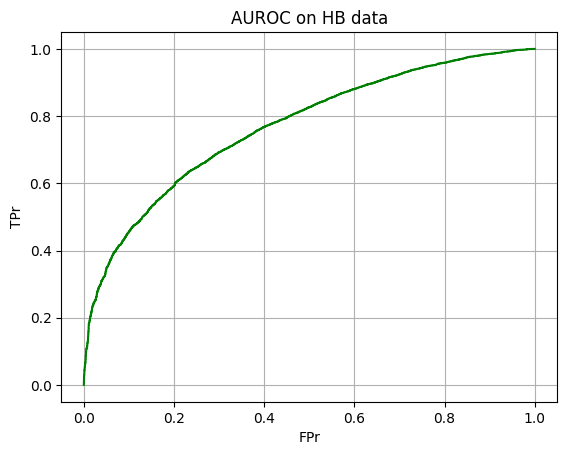

In [123]:
plt.plot(FPr , TPr , color = "Green")
plt.xlabel("FPr")
plt.ylabel("TPr")
plt.title("AUROC on HB data")
plt.grid()

---

**Decision Tree**

In [124]:
from sklearn.model_selection import train_test_split

df_train , df_test = train_test_split(df , test_size=.2)

df_train_x = df_train.drop(["is_canceled"] , axis = 1)
df_train_y = df_train.is_canceled

df_test_x = df_test.drop(["is_canceled"] ,  axis = 1)
df_test_y = df_test.is_canceled

In [125]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(df_train_x , df_train_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [126]:
pred_dt = dt.predict(df_test_x)

In [127]:
from sklearn.metrics import *

In [128]:
tab = confusion_matrix(df_test_y , pred_dt)
tab

array([[13111,  1970],
       [ 1873,  6924]])

In [129]:
tab_cm = pd.DataFrame(tab)
tab_cm.columns = ["NC" , "C"]
tab_cm.index = ["NC" , "C"]
tab_cm

,NC,C
NC,13111,1970
C,1873,6924


In [130]:
print(classification_report(df_test_y , pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87     15081
           1       0.78      0.79      0.78      8797

    accuracy                           0.84     23878
   macro avg       0.83      0.83      0.83     23878
weighted avg       0.84      0.84      0.84     23878



**Feature importance**

In [131]:
dt.feature_importances_

array([0.01078475, 0.14259284, 0.03059995, 0.01428195, 0.0547087 ,
       0.06319816, 0.02193814, 0.03439594, 0.01275273, 0.00610281,
       0.00067824, 0.08390757, 0.00083173, 0.02329866, 0.0069368 ,
       0.0137514 , 0.01991983, 0.01751656, 0.2334653 , 0.00179127,
       0.04214011, 0.11053736, 0.02393707, 0.02993212])

In [132]:
dt.feature_importances_.sum()

np.float64(1.0)

In [133]:
feature_imp = pd.DataFrame()
feature_imp["Features"] = df_train_x.columns
feature_imp["Importance"] = dt.feature_importances_
feature_imp = feature_imp.sort_values("Importance" , ascending= False)
feature_imp

,Features,Importance
18,deposit_type,0.233465
1,lead_time,0.142593
21,adr,0.110537
11,country,0.083908
5,arrival_date_day_of_month,0.063198
4,arrival_date_week_number,0.054709
20,customer_type,0.042140
7,stays_in_week_nights,0.034396
2,arrival_date_year,0.030600
23,total_of_special_requests,0.029932


In [134]:
l1 = list(feature_imp.Features[0:20])
l1.append("is_canceled")

In [135]:
hb = df.loc[: , l1]

In [136]:
from sklearn.model_selection import train_test_split

df_train , df_test = train_test_split(hb , test_size=.2)

df_train_x = df_train.drop(["is_canceled"] , axis = 1)
df_train_y = df_train.is_canceled

df_test_x = df_test.drop(["is_canceled"] ,  axis = 1)
df_test_y = df_test.is_canceled

In [137]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(df_train_x , df_train_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [138]:
pred_dt = dt.predict(df_test_x)

In [139]:
from sklearn.metrics import *

In [142]:
tab = confusion_matrix(df_test_y , pred_dt)
tab

array([[13123,  2045],
       [ 1808,  6902]])

In [143]:
tab_cm = pd.DataFrame(tab)
tab_cm.columns = ["NC" , "C"]
tab_cm.index = ["NC" , "C"]
tab_cm

,NC,C
NC,13123,2045
C,1808,6902


In [144]:
print(classification_report(df_test_y , pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87     15168
           1       0.77      0.79      0.78      8710

    accuracy                           0.84     23878
   macro avg       0.83      0.83      0.83     23878
weighted avg       0.84      0.84      0.84     23878



---

**Random Forest**

In [145]:
from sklearn.model_selection import train_test_split

df_train , df_test = train_test_split(df , test_size=.2)

df_train_x = df_train.drop(["is_canceled"] , axis = 1)
df_train_y = df_train.is_canceled

df_test_x = df_test.drop(["is_canceled"] ,  axis = 1)
df_test_y = df_test.is_canceled

In [146]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=50)
rfc.fit(df_train_x , df_train_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [147]:
pred_rfc = rfc.predict(df_test_x)

In [148]:
tab_rfc = confusion_matrix(df_test_y , pred_rfc)
tab_rfc

array([[14117,   943],
       [ 1843,  6975]])

In [149]:
tab_cm = pd.DataFrame(tab)
tab_cm.columns = ["NC" , "C"]
tab_cm.index = ["NC" , "C"]
tab_cm

,NC,C
NC,13123,2045
C,1808,6902


In [150]:
print(classification_report(df_test_y , pred_rfc))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91     15060
           1       0.88      0.79      0.83      8818

    accuracy                           0.88     23878
   macro avg       0.88      0.86      0.87     23878
weighted avg       0.88      0.88      0.88     23878



---

**Gradient boosting (Advance ML)**

In [151]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# model
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# train
gb.fit(df_train_x, df_train_y)

# predictions
pred_gb = gb.predict(df_test_x)
pred_gb_prob = gb.predict_proba(df_test_x)[:, 1]

# evaluation
print(classification_report(df_test_y, pred_gb))
print("ROC-AUC:", roc_auc_score(df_test_y, pred_gb_prob))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87     15060
           1       0.84      0.67      0.75      8818

    accuracy                           0.83     23878
   macro avg       0.83      0.80      0.81     23878
weighted avg       0.83      0.83      0.83     23878

ROC-AUC: 0.9075569461776392
